<a href="https://colab.research.google.com/github/vsanzi22/herramientasbasicas-sanzi-valeria/blob/main/An%C3%A1lisis_de_Transacciones_con_Tarjeta_de_Cr%C3%A9dito_(2019%E2%80%932020).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Transacciones con Tarjeta de Crédito (2019–2020)
## Detección de patrones de fraude en contexto pandémico

*  Autora: Valeria Alejandra Sanzi
*  Curso: Herramientas básicas para el Análisis de Datos — UTN BA
*  Dataset: Credit Card Transactions Fraud Detection (Kaggle)


# Objetivo
El presente proyecto analiza un dataset sintético de transacciones realizadas con tarjeta de crédito durante el período 2019–2020, generado mediante simulación computacional y publicado en Kaggle. El dataset incluye tanto transacciones legítimas como fraudulentas, lo que permite explorar patrones de comportamiento diferenciados entre ambas clases. El análisis se enmarca en un contexto de particular relevancia: el período abarca el inicio de la pandemia de COVID-19, momento en que los hábitos de consumo y los vectores de fraude financiero experimentaron transformaciones significativas.

# Pregunta principal y KPIs
¿Cómo evolucionó el comportamiento de las transacciones con tarjeta de crédito entre 2019 y 2020, y qué patrones distinguen a las transacciones fraudulentas de las legítimas en términos de monto, categoría y distribución temporal?
Tiene dos ejes claros: el temporal (evolución, impacto COVID) y el comparativo (fraude vs. no fraude).

Para profundizar el análisis: ¿Existe alguna franja horaria o día de la semana donde se concentre desproporcionadamente el fraude?

## Key Performance Indicators
KPI 1 — Tasa de fraude mensual: porcentaje de transacciones fraudulentas sobre el total, mes a mes. Te permite ver si el fraude aumentó durante la pandemia.

KPI 2 — Monto promedio por tipo de transacción: comparando el ticket promedio de transacciones fraudulentas vs. legítimas. Casi siempre hay una diferencia marcada y es visualmente muy impactante en Power BI.

KPI 3 — Concentración de fraude por categoría de comercio: qué rubros (grocery, entertainment, travel, etc.) concentran más fraude. Esto conecta directamente con el contexto pandémico, porque el patrón de consumo cambió radicalmente en 2020.



# Importación de librerias

In [ ]:
# Importo librerías necesarias para la limpieza y análisis del archivo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carga de datos y primera exploración

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Data/Trabajo Final/fraudTrain.csv')
df.shape        # cuántas filas y columnas
df.head()       # primeras filas
df.dtypes       # tipos de datos
df.info()       # resumen general

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 1

In [ ]:
# Auditoria de calidad
df.isnull().sum()       # nulos por columna
df.duplicated().sum()   # filas duplicadas
df.describe()           # estadísticas básicas

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


#Diccionario

*   Unnamed: numeración de filas.
*   trans_date_trans_time: fecha y hora de transacción.
*   cc_num: Número de tarjeta de crédito del titular
*   merchant: Nombre del comercio donde se realizó la transacción
*   category: Categoría del comercio (ej: supermercado, entretenimiento, viajes)
*   amt: Monto de la transacción en dólares
*   first: Nombre del titular de la tarjeta.
*   last: Apellido del titular de la tarjeta.
*   gender: Género del titular de la tarjeta
*   street: Dirección de vivienda del titular de la tarjeta.
*   city: Ciudad donde se encuentra el titular de la tarjeta.
*   state: Estado donde se encuentra el titular de la tarjeta.
*   zip: Código postal del titular de la tarjeta
*   lat: Latitud de la ubicación del titular de la tarjeta
*   long: Longitud de la ubicación del titular de la tarjeta
*   city_pop: Población de la ciudad del titular de la tarjeta
*   dob: Fecha de nacimiento del titular de la tarjeta
*   trans_num: Número de transacción
*   unix_time: Tiempo de la transacción en formato UNIX
*   merch_lat: Latitud de la ubicación del comercio
*   merch_long: Latitud de la ubicación del comercio
*   is_fraud: Indicador de fraude. Variable objetivo: 1 = transacción fraudulenta, 0 = transacción legítima.

Serán agregadas las siguientes columnas:
*   mes: Mes extraído de la fecha de transacción
*   hora: Hora extraída de la fecha de transacción
*   dia_semana: Día de la semana extraído de la fecha de transacción
*   año: Año extraído de la fecha de transacción

# Limpieza
Una vez revisados los tipos de datos, de la columna trans_date_trans_time serán extraidos los datos hora, mes, nombre de día de la semana y año. Esto servirá a la hora de analizar los KPIs.

A la hora de realizar el análisis, es de poca importancia cuestiones como nombres propios o puntos geográficos. Por lo que se verán eliminadas las siguientes columnas:


*   First
*   Last
*   Street
*   City
*   Zip
*   Lat
*   Long
*   Merch_long
*   Merch_lat



In [ ]:
# Limpieza
# Convertir la fecha a formato datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extraer columnas útiles para el análisis temporal
df['mes'] = df['trans_date_trans_time'].dt.month
df['hora'] = df['trans_date_trans_time'].dt.hour
df['dia_semana'] = df['trans_date_trans_time'].dt.day_name()
df['año'] = df['trans_date_trans_time'].dt.year

# Eliminar columnas sin utilidad
columnas_a_eliminar = ['first', 'last', 'street', 'city', 'zip',
                        'lat', 'long', 'merch_lat', 'merch_long']
df = df.drop(columns=columnas_a_eliminar, errors='ignore')

In [ ]:
df.shape        # confirmar que no se perdieron filas
df.dtypes       # confirmar que los tipos quedaron bien
df.head()       # visual rápido del dataframe limpio

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,gender,state,city_pop,job,dob,trans_num,unix_time,is_fraud,mes,hora,dia_semana,año
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,NC,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,0,1,0,Tuesday,2019
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,WA,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,0,1,0,Tuesday,2019
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,ID,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,0,1,0,Tuesday,2019
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,MT,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,0,1,0,Tuesday,2019
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,VA,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,0,1,0,Tuesday,2019


# Análisis exploatorio EDA

## Gráfico 1 — Evolución mensual de transacciones (legítimas vs. fraudulentas)

Tipo: línea doble

Responde a: KPI 1 (tasa de fraude mensual) y al eje temporal de la pregunta principal.

Los siguientes tres gráficos analizan la evolución temporal de las transacciones. El primero ofrece una visión comparativa general, mientras que los dos siguientes permiten apreciar con mayor detalle el comportamiento individual de cada clase.

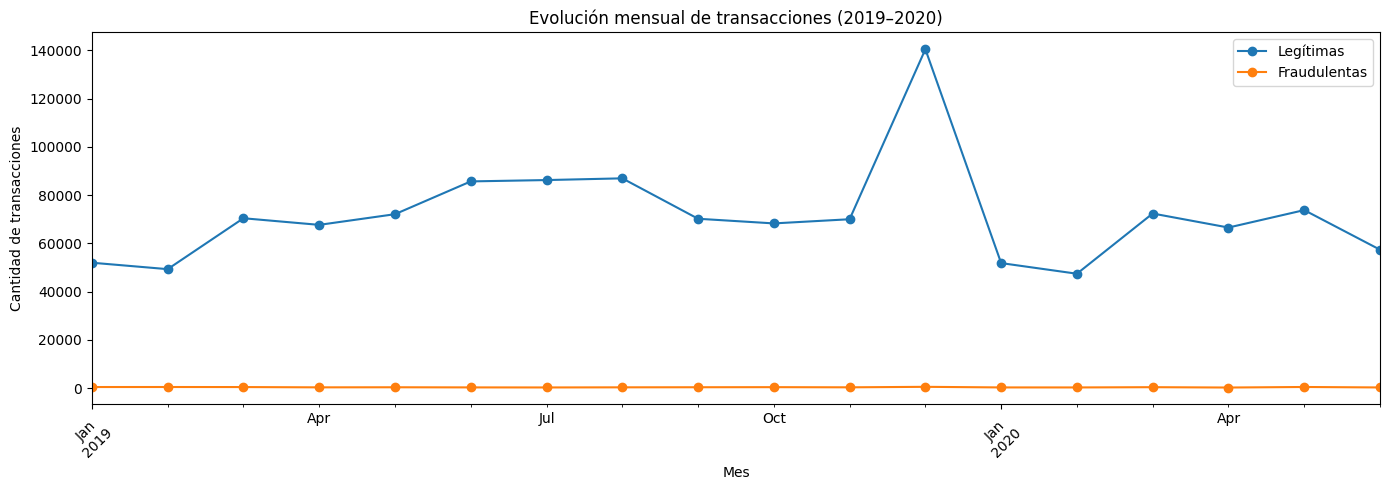

In [ ]:
# Agrupar por año-mes y tipo
df['año_mes'] = df['trans_date_trans_time'].dt.to_period('M')
evolucion = df.groupby(['año_mes', 'is_fraud']).size().unstack()
evolucion.columns = ['Legítimas', 'Fraudulentas']

evolucion.plot(figsize=(14, 5), marker='o')
plt.title('Evolución mensual de transacciones (2019–2020)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de transacciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico revela que las transacciones fraudulentas representan una proporción minoritaria pero constante del total durante todo el período analizado. Las transacciones legítimas muestran un pico notable en noviembre de 2019, consistente con la estacionalidad de fin de año. Llamativamente, no se observa una caída significativa en el volumen de transacciones durante los primeros meses de la pandemia de COVID-19 (marzo–abril 2020), lo que sugiere una rápida adaptación al consumo digital.

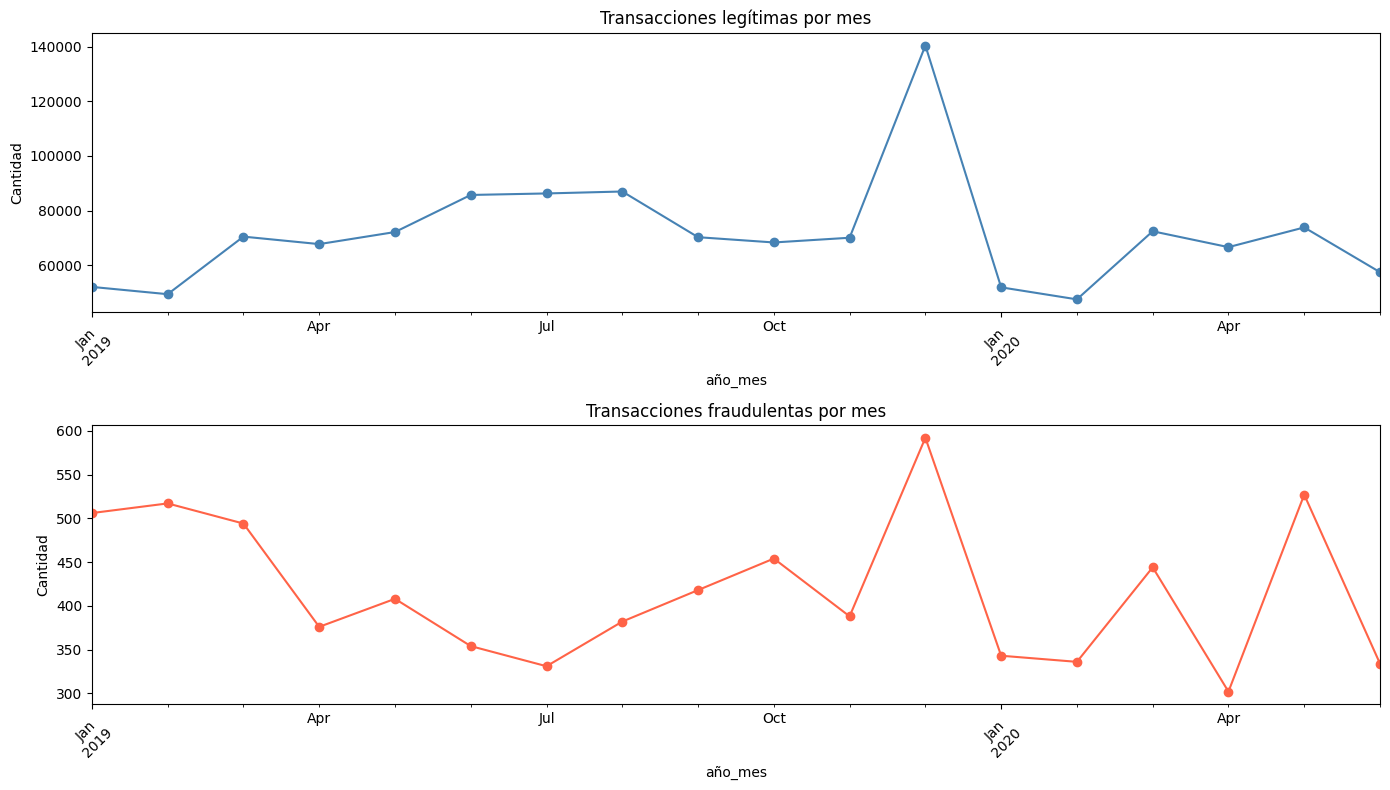

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

evolucion['Legítimas'].plot(ax=ax1, marker='o', color='steelblue')
ax1.set_title('Transacciones legítimas por mes')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=45)

evolucion['Fraudulentas'].plot(ax=ax2, marker='o', color='tomato')
ax2.set_title('Transacciones fraudulentas por mes')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##   Gráfico 2 — Distribución de montos: fraude vs. legítimas

Tipo: boxplot

Responde a: KPI 2 (monto promedio por tipo de transacción).

Para este análisis se utilizó nuevamente el recurso de dos gráficos complementarios. El primero ofrece una vista completa de la distribución de montos, donde se evidencia la presencia significativa de outliers en las transacciones legítimas. El segundo presenta un plano recortado (eje Y limitado a USD 1.500) que permite comparar con mayor claridad la distribución central de ambas clases.

/tmp/ipykernel_30788/1617502207.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legítima', 'Fraudulenta'])


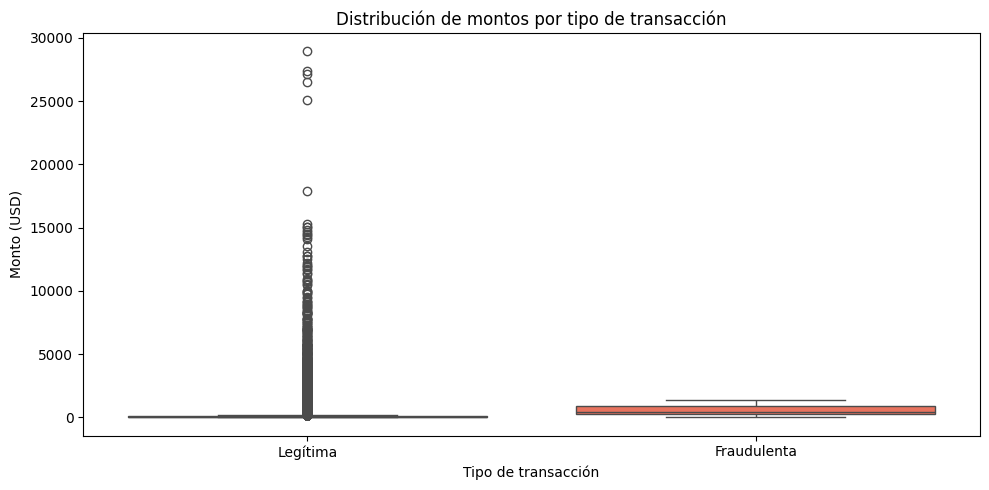

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='is_fraud', y='amt',
            hue='is_fraud', palette={0: 'steelblue', 1: 'tomato'}, legend=False)
ax.set_xticklabels(['Legítima', 'Fraudulenta'])
ax.set_title('Distribución de montos por tipo de transacción')
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('Monto (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_30788/2784243266.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legítima', 'Fraudulenta'])


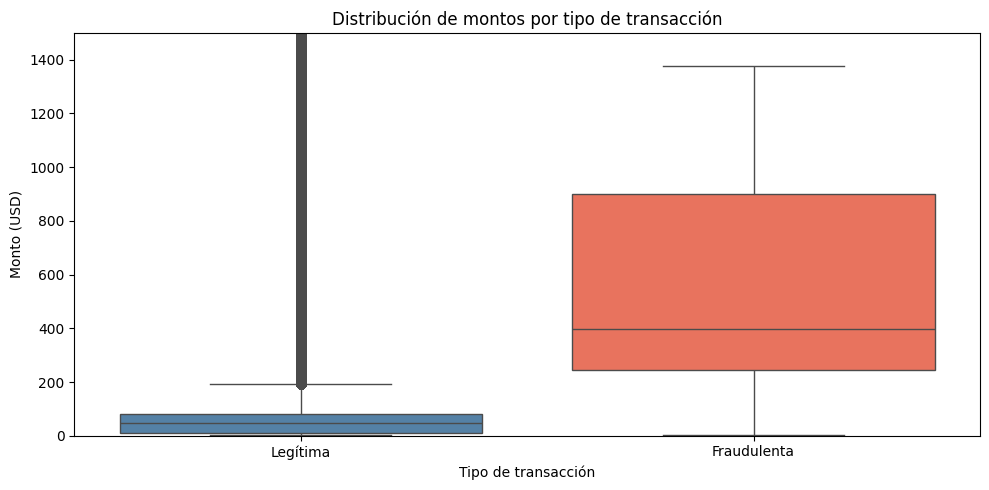

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='is_fraud', y='amt',
            hue='is_fraud', palette={0: 'steelblue', 1: 'tomato'}, legend=False)
ax.set_xticklabels(['Legítima', 'Fraudulenta'])
ax.set_title('Distribución de montos por tipo de transacción')
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('Monto (USD)')
ax.set_ylim(0, 1500)  # ajustá este valor según lo que veas en tus datos
plt.tight_layout()
plt.show()

Las transacciones legítimas presentan una distribución altamente sesgada con numerosos outliers, mientras que las fraudulentas muestran montos significativamente más altos y una menor dispersión relativa. Esto sugiere que el monto de la transacción podría ser una variable relevante para la detección de fraude.

##   Gráfico 3 — Tasa de fraude por categoría de comercio

Tipo: barras horizontales ordenadas

Responde a: KPI 3 (concentración de fraude por categoría).

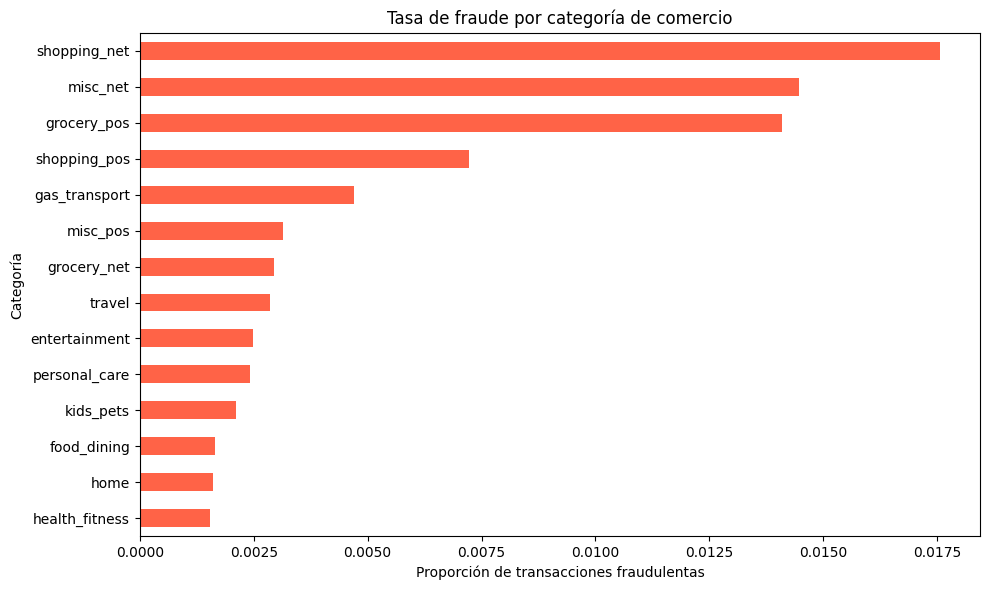

In [ ]:
fraude_categoria = df.groupby('category')['is_fraud'].mean().sort_values()

fraude_categoria.plot(kind='barh', figsize=(10, 6), color='tomato')
plt.title('Tasa de fraude por categoría de comercio')
plt.xlabel('Proporción de transacciones fraudulentas')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

El gráfico revela que las categorías con mayor tasa de fraude corresponden a comercios digitales, particularmente compras en línea y transacciones misceláneas por internet. Esta concentración resulta coherente con el contexto pandémico del período analizado, durante el cual el consumo migró masivamente hacia canales digitales, ampliando a su vez la superficie de exposición al fraude.

En el extremo opuesto, categorías como *home* y *health_fitness* registran las tasas más bajas. Una posible explicación es que estos rubros, al requerir presencia física o tratarse de servicios de baja frecuencia de transacción, ofrecieron menos oportunidades para la actividad fraudulenta durante el período.

##  Gráfico 4 — Distribución horaria del fraude

Tipo: barras

Responde a: la subpregunta sobre concentración horaria.

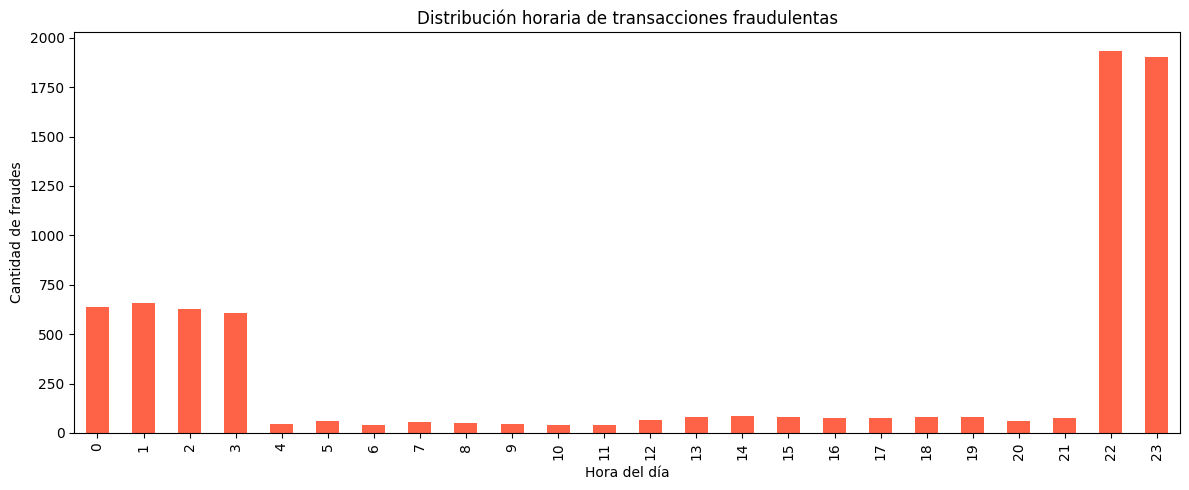

In [ ]:
fraude_hora = df[df['is_fraud'] == 1].groupby('hora').size()

fraude_hora.plot(kind='bar', figsize=(12, 5), color='tomato')
plt.title('Distribución horaria de transacciones fraudulentas')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de fraudes')
plt.tight_layout()
plt.show()

El gráfico evidencia un patrón marcadamente nocturno en la distribución de transacciones fraudulentas. El horario pico se concentra entre las 22hs y las 3hs, franja en la que los titulares de las tarjetas se encuentran presumiblemente inactivos, reduciendo significativamente la probabilidad de detección inmediata de movimientos irregulares.

En contraste, la franja comprendida entre las 4hs y las 11hs registra los niveles más bajos de fraude. Este valle podría explicarse por una combinación de menor actividad general de transacciones y el inicio del período de vigilia de los titulares, que aumenta la probabilidad de monitoreo activo de sus cuentas.

Desde una perspectiva de gestión del riesgo, este patrón sugiere que los sistemas de alerta temprana y verificación adicional deberían intensificarse durante la franja nocturna, particularmente entre las 22hs y las 3hs.

##   Gráfico 5 — Fraude por día de la semana

Tipo: barras ordenadas de lunes a domingo

Responde a: la subpregunta de patrón semanal.

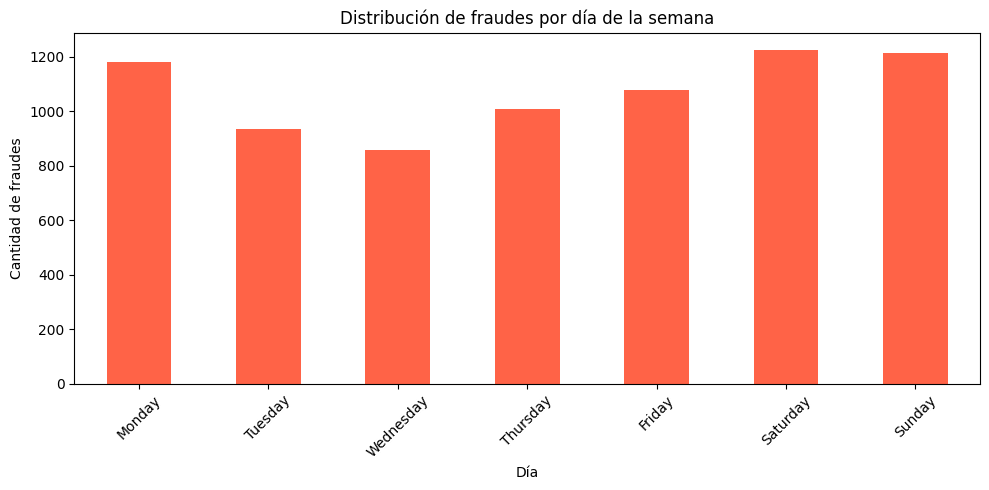

In [ ]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday',
              'Thursday', 'Friday', 'Saturday', 'Sunday']

fraude_dia = df[df['is_fraud'] == 1]['dia_semana'].value_counts()
fraude_dia = fraude_dia.reindex(orden_dias)

fraude_dia.plot(kind='bar', figsize=(10, 5), color='tomato')
plt.title('Distribución de fraudes por día de la semana')
plt.xlabel('Día')
plt.ylabel('Cantidad de fraudes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico muestra que la actividad fraudulenta presenta su mayor concentración entre el viernes y el lunes, con el pico iniciándose a fin de semana y extendiéndose hacia el inicio de la semana. Este patrón resulta coherente con una menor capacidad operativa de los equipos antifraude bancarios durante los fines de semana, lo que podría ampliar la ventana de tiempo disponible para que las transacciones fraudulentas pasen desapercibidas antes de ser detectadas y bloqueadas.

Los martes y miércoles, en contraposición, registran los niveles más bajos de incidencia, sugiriendo que la plena operatividad de los sistemas de monitoreo durante los días hábiles centrales actúa como factor disuasivo.

# Conclusiones e insights principales

## Respuesta a la pregunta principal
El análisis de las transacciones con tarjeta de crédito durante el período 2019–2020 permitió identificar patrones claros que distinguen el comportamiento fraudulento del legítimo en tres dimensiones: temporal, económica y comercial.

Las transacciones fraudulentas representaron una proporción minoritaria pero constante del total, sin mostrar una correlación directa con el incremento del volumen general de transacciones. Llamativamente, el inicio de la pandemia de COVID-19 no generó una caída significativa en el volumen de transacciones legítimas, lo que sugiere una rápida adaptación al consumo digital.

## Síntesis de los KPIs
En relación a los KPIs definidos al inicio del proyecto:

KPI 1 — Tasa de fraude mensual: el fraude se mantuvo estable a lo largo del período sin picos estacionales significativos, a diferencia de las transacciones legítimas que mostraron un pico notable en noviembre de 2019 asociado a la temporada de fin de año.

KPI 2 — Monto promedio por tipo de transacción: las transacciones fraudulentas tienden a concentrarse en un rango de montos más acotado que las legítimas, las cuales presentan una dispersión significativamente mayor con numerosos outliers de alto valor.

KPI 3 — Concentración de fraude por categoría: el fraude se concentra desproporcionadamente en categorías de comercio digital, coherente con el contexto pandémico que aceleró la migración hacia canales en línea.

Perfil temporal del fraude y cierre

El hallazgo más relevante del análisis surge de la combinación de los patrones horario y semanal: el momento de mayor vulnerabilidad se produce entre el viernes y el lunes durante la franja nocturna de 22hs a 3hs. Esta convergencia entre la menor operatividad de los equipos antifraude durante el fin de semana y la inactividad del titular de la tarjeta configura una ventana de exposición sistemática y predecible.

Como limitación del presente análisis cabe destacar que el dataset utilizado es de naturaleza sintética, por lo que los patrones identificados, si bien analíticamente válidos, no necesariamente reflejan la distribución real del fraude en el sistema financiero. Como posible extensión del trabajo, resultaría de interés aplicar modelos de clasificación supervisada para evaluar la capacidad predictiva de las variables analizadas.